c:\Users\Дио\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.263e+12, tolerance: 2.207e+10
  model = cd_fast.enet_coordinate_descent(



Используемая модель: lasso
Результаты:
{'MAE': 50670.609700814624, 'R2': 0.6254370890674734}


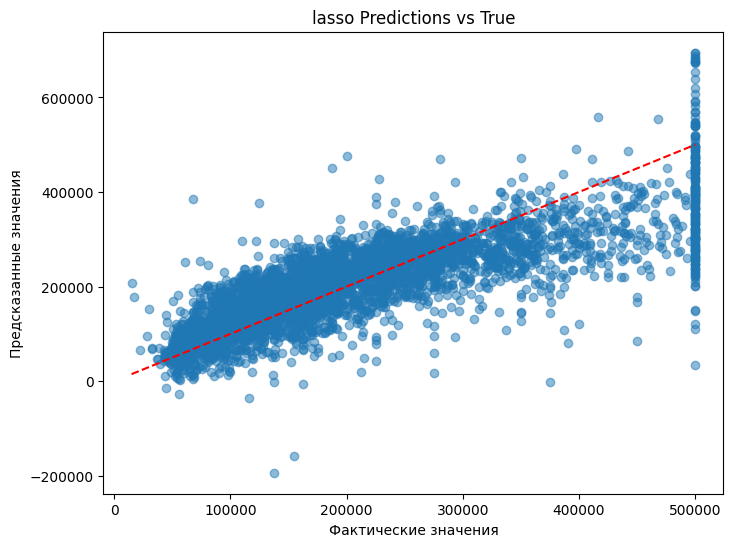

Эта модель не имеет attribute feature_importances_


In [1]:
from sklearn.model_selection import train_test_split

from src.data_loader import load_data
from src.utils import split_features_target
from src.preprocessing import build_preprocessor
from src.model import build_model
from src.evaluation import evaluate
from src.visualization import plot_predictions, plot_feature_importance


# ===============================
# ОСНОВНЫЕ НАСТРОЙКИ
# ===============================

DATA_PATH = "data/housing.csv"        # путь к файлу с данными
TARGET_COLUMN = "median_house_value"  # целевая колонка
MODEL_NAME = "lasso"                  # используемая модель


# ----------------------------------
# ВЫБОР МОДЕЛИ:
# "xgb"           → XGBoost
# "lgbm"          → LightGBM
# "catboost"      → CatBoost
# "rf"            → RandomForest
# "extra_trees"   → ExtraTrees
# "gb"            → GradientBoosting
# "hist_gb"       → HistGradientBoosting
# "linear"        → LinearRegression
# "ridge"         → Ridge
# "lasso"         → Lasso
# "elastic"       → ElasticNet
# ----------------------------------


def main():

    # ==========================================
    # 1️⃣ Загрузка данных
    # ==========================================
    df = load_data(DATA_PATH)

    # ==========================================
    # 2️⃣ Разделение на признаки и цель
    # ==========================================
    X, y = split_features_target(df, TARGET_COLUMN)

    # ==========================================
    # 3️⃣ Train / Test split
    # ==========================================
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42
    )

    # ==========================================
    # 4️⃣ Построение препроцессора
    # ==========================================
    preprocessor = build_preprocessor(X)

    # ==========================================
    # 5️⃣ Создание модели (Pipeline)
    # ==========================================
    model = build_model(
        preprocessor,
        model_name=MODEL_NAME
    )

    # ==========================================
    # 6️⃣ Обучение + оценка
    # ==========================================
    results = evaluate(
        model,
        X_train,
        X_test,
        y_train,
        y_test
    )

    # ==========================================
    # 7️⃣ Вывод результатов
    # ==========================================
    print(f"\nИспользуемая модель: {MODEL_NAME}")

    print("Результаты:")
    print({
        "MAE": results["MAE"],
        "R2": results["R2"]
    })

    # ==========================================
    # 8️⃣ Графики
    # ==========================================

    plot_predictions(
        y_test,
        results["predictions"],
        MODEL_NAME
    )

    plot_feature_importance(
        model,
        X.columns
    )


if __name__ == "__main__":
    main()

In [1]:
from sklearn.model_selection import train_test_split

from src.data_loader import load_data
from src.utils import split_features_target
from src.preprocessing import build_preprocessor
from src.model import build_model
from src.evaluation import evaluate


# ===============================
# ОСНОВНЫЕ НАСТРОЙКИ
# ===============================

DATA_PATH = "data/housing.csv"
TARGET_COLUMN = "median_house_value"


# список всех моделей
MODELS = [
    "xgb",
    "lgbm",
    "catboost",
    "rf",
    "extra_trees",
    "gb",
    "hist_gb",
    "linear",
    "ridge",
    "lasso",
    "elastic"
]


def main():

    # ==========================================
    # 1️⃣ Загрузка данных
    # ==========================================
    df = load_data(DATA_PATH)

    # ==========================================
    # 2️⃣ Разделение на признаки и цель
    # ==========================================
    X, y = split_features_target(df, TARGET_COLUMN)

    # ==========================================
    # 3️⃣ Train / Test split
    # ==========================================
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42
    )

    # ==========================================
    # 4️⃣ Препроцессор
    # ==========================================
    preprocessor = build_preprocessor(X)

    # ==========================================
    # 5️⃣ Запуск всех моделей
    # ==========================================
    results_table = []

    for model_name in MODELS:

        print(f"\nЗапуск модели: {model_name}")

        model = build_model(
            preprocessor,
            model_name=model_name
        )

        results = evaluate(
            model,
            X_train,
            X_test,
            y_train,
            y_test
        )

        results_table.append({
            "model": model_name,
            "MAE": results["MAE"],
            "R2": results["R2"]
        })

        print("MAE:", results["MAE"])
        print("R2:", results["R2"])

    # ==========================================
    # 6️⃣ Итоговая таблица
    # ==========================================
    print("\n===============================")
    print("ИТОГОВЫЕ РЕЗУЛЬТАТЫ МОДЕЛЕЙ")
    print("===============================")

    results_table = sorted(results_table, key=lambda x: x["R2"], reverse=True)

    for r in results_table:
        print(r)


if __name__ == "__main__":
    main()


Запуск модели: xgb
MAE: 30232.196695963543
R2: 0.8411076098521669

Запуск модели: lgbm
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000881 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1846
[LightGBM] [Info] Number of data points in the train set: 16512, number of used features: 12
[LightGBM] [Info] Start training from score 207194.693738


c:\Users\Дио\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


MAE: 30207.946154381883
R2: 0.8419903190696996

Запуск модели: catboost
MAE: 32603.210451008956
R2: 0.8212783203481644

Запуск модели: rf
MAE: 32932.644813953484
R2: 0.8107371995424423

Запуск модели: extra_trees
MAE: 33858.872998223516
R2: 0.8041014432171438

Запуск модели: gb
MAE: 34919.75352856808
R2: 0.7971627316357269

Запуск модели: hist_gb
MAE: 30942.63035658999
R2: 0.8363157304152318

Запуск модели: linear
MAE: 50670.48923565362
R2: 0.6254382675296266

Запуск модели: ridge
MAE: 50676.92217059707
R2: 0.6253652564019248

Запуск модели: lasso
MAE: 50670.609700814624
R2: 0.6254370890674734

Запуск модели: elastic
MAE: 50852.25380344166
R2: 0.6225940601372906

ИТОГОВЫЕ РЕЗУЛЬТАТЫ МОДЕЛЕЙ
{'model': 'lgbm', 'MAE': 30207.946154381883, 'R2': 0.8419903190696996}
{'model': 'xgb', 'MAE': 30232.196695963543, 'R2': 0.8411076098521669}
{'model': 'hist_gb', 'MAE': 30942.63035658999, 'R2': 0.8363157304152318}
{'model': 'catboost', 'MAE': 32603.210451008956, 'R2': 0.8212783203481644}
{'model': '

c:\Users\Дио\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.263e+12, tolerance: 2.207e+10
  model = cd_fast.enet_coordinate_descent(
